<a href="https://colab.research.google.com/github/jlloring/ST-554_JLoring/blob/main/Loring_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ST 554 Homework 5**
---
Authored by: Jamie Loring

In [1]:
# importing required modules:
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import sqlite3

## **Part 1: Concepts**

#### **Question 1**
An example of a place where I have encountered big data is with the popular music streaming service, Spotify.
- **Volume:** Spotify handles a large scale of data in terms of its users, the songs that are streamed, the playlists that are created, the songs that are liked, etc.
- **Velocity:** Spotify streams its data in real time. *Discover Weekly* playlists are curated each week based on a user's listening history. When a song is skipped, this effects future recommendations. All listening habits are tracked to provide dynamic and personalized recommendations for future listening.
- **Variety:** Spotify handles different forms of data. In addition to each unique user profile, there are also different subscription plans. Users can create their own playlists and even share them with others in a collaborative manner. In addition to songs, Spotify also has podcasts available.
- **Veracity (Variability):** This V comes into play when Spotify's algorithm gets it wrong. Besides the obvious variation in filtering out bots/fake users, if the metadata is incorrect, this can negatively impact a user's recommendations. This can lead to inaccurate personalization of one's profile.
- **Value:** Spotify is a valuable form of big data. As a user myself, I particularly enjoy the *Discover Weekly* playlist because it exposes me to new music based on songs that I have liked. It also recommends new artists based on the ones that I have listened to. The data that Spotify collects allows it to personalize each user's experience, which makes it invaluable.

#### **Question 2**
The database that we will use in part IV consists of Major League Baseball (MLB) data. Common database actions are represented by the `CRUD` acronym:
- **C**reate data: An example of this would be adding a new person (presumably a player) into the `Person` table.
- **R**ead data: An example of this would be running a query to return all pitchers who have pitched at least 3 complete games within their season.
- **U**pdate data: An example of this would be updating any data that is incorrect, i.e., fixing a typo with the correct name of an MLB park.
- **D**elete data: An example of fthis would be removing a duplicate player entry from the `Person` table.

#### **Question 3**
The purpose of the `HAVING` clause when writing SQL code is similar to the `WHERE` clause in that it specifies a filter condition, but there are key differences these two clauses. `HAVING` goes *AFTER* the `GROUP BY` clause, but `WHERE` goes before the `GROUP BY` clause. Furthermore, if a `HAVING` clause is used, a `GROUP BY` clause must be used as well. This is not true with a `WHERE` clause; this can be used with or without `GROUP BY`. Since `HAVING` goes after the `GROUP BY` clause, the filtering is done on groups rather than individual rows (this is the case with `WHERE`). As a result, the `HAVING` clause can accomodate aggregate functions used in the `SELECT` statement, but the `WHERE` clause cannot.

## **Part 2: Simulation of a Sampling Distribution**

#### **Question 4**

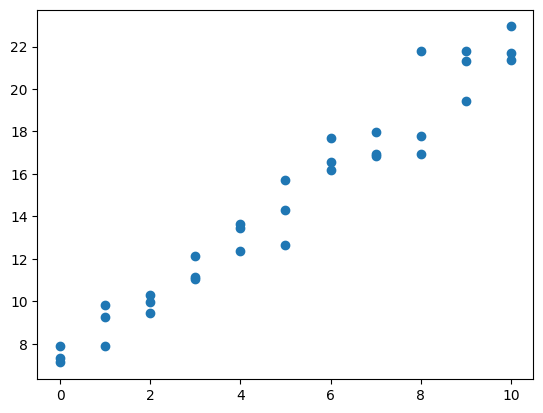

In [9]:
#modules already imported at beginning of notebook
rng= default_rng(32)
beta_0= 7
beta_1= 1.5
# get three'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start= 0, stop= 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y= beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x= x, y= y)
plt.show()

## **Part 3: Big Data Examples & Rare Events**

#### **Question 5**

#### **Question 6**

#### **Question 7**

## **Part 4: Querying a database**

#### **Question 8**

The code below connects to the database that is uploaded to Colab.

In [12]:
con = sqlite3.connect("lahman_1871-2022.sqlite")

Continuing on, the code below looks at all the tables in the database. In addition, the `read_sql()` function from `pandas` is used to have this result returned as a data frame.

In [13]:
#SQL query to return all table names in the database
get_schema = '''
             select *
             from sqlite_schema
             where type = 'table';
             '''
#puts result of SQL query into pandas df -- don't need a cursor object!
schema_df = pd.read_sql(get_schema, con)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


#### **Question 9**
The code below writes an SQL query with `pd.read_sql()` to return all the teams that played in 2015. Only the `yearID` and `name` columns from the `Teams` table are returned.

In [16]:
q9 = '''
     select yearID, name
     from Teams
     where yearID = 2015;
     '''

teams_2015 = pd.read_sql(q9, con)
teams_2015

,yearID,name
0,2015,Baltimore Orioles
1,2015,Boston Red Sox
2,2015,Chicago White Sox
3,2015,Cleveland Indians
4,2015,Detroit Tigers
5,2015,Houston Astros
6,2015,Kansas City Royals
7,2015,Los Angeles Angels of Anaheim
8,2015,Minnesota Twins
9,2015,New York Yankees


#### **Question 10**
The code below writes an SQL query with `pd.read_sql()` to return all of the players in the hall of fame, the year they were voted into the hall of fame, and their category.

In [19]:
q10 = '''
     select playerID, yearid, category
     from HallOfFame
     where inducted = 'Y';
     '''

HOF = pd.read_sql(q10, con)
HOF

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


#### **Question 11**
NEED TO CHECK
The code below writes an SQL query with `pd.read_sql()` to return all unique managers of the Pittsburgh Pirates and only that information from the `Managers` table.

In [23]:
q11 = '''
     select distinct *
     from Managers
     where teamID = 'PIT';
     '''

mgr = pd.read_sql(q11, con)
mgr

,playerID,yearID,teamID,lgID,inseason,G,W,L,rank,plyrMgr
0,phillho99,1887,PIT,NL,1,125,55,69,6,N
1,phillho99,1888,PIT,NL,1,139,66,68,6,N
2,phillho99,1889,PIT,NL,1,71,28,43,5,N
3,dunlafr01,1889,PIT,NL,2,17,7,10,5,Y
4,hanlone01,1889,PIT,NL,3,46,26,18,5,Y
...,...,...,...,...,...,...,...,...,...,...
151,hurdlcl01,2019,PIT,NL,1,159,68,91,5,N
152,princto01,2019,PIT,NL,2,3,1,2,5,N
153,sheltde99,2020,PIT,NL,1,60,19,41,5,N
154,sheltde99,2021,PIT,NL,1,162,61,101,5,N


#### **Question 12**

#### **Question 13**